# 08 — Modeling

Goal: find the best classifier for the news source classification task and understand what it's learning.

Sections:
1. Data loading and train/test split
2. Baseline — TF-IDF logistic regression (reproduce assignment baseline)
3. MiniLM embeddings — logistic regression, SVM, random forest
4. Model comparison and selection
5. Error analysis — what is the best model getting wrong?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer

plt.rcParams['figure.dpi'] = 120
FOX_COLOR = '#E81B23'
NBC_COLOR = '#2A5EAC'

/Users/rohankrishnan/Documents/GitHub/cis-5190-news/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 — Data Loading and Train/Test Split

In [3]:
df = pd.read_csv('../data/processed/combined_base_data.csv')
df['datetime_posted'] = pd.to_datetime(df['datetime_posted'], utc=True, format = "mixed")
df = df.dropna(subset=['title']).copy()

print(f'Total articles: {len(df):,}')
print(f'Missing datetimes: {df["datetime_posted"].isna().sum()}')
print(f'Fox: {df["is_fox"].sum():,} | NBC: {(df["is_fox"]==0).sum():,}')

Total articles: 3,801
Missing datetimes: 90
Fox: 2,000 | NBC: 1,801


In [4]:
# Time-based split on rows with valid datetimes
# Rows missing datetimes go into training only — we don't want them in the test set
# since we can't verify their temporal position
df_dated = df.dropna(subset=['datetime_posted']).sort_values('datetime_posted')
df_undated = df[df['datetime_posted'].isna()]

split_idx = int(len(df_dated) * 0.8)
train_dated = df_dated.iloc[:split_idx]
test = df_dated.iloc[split_idx:]

# Combine dated train rows with undated rows for training
train = pd.concat([train_dated, df_undated], ignore_index=True)

print(f'Train: {len(train):,} | Fox%: {train["is_fox"].mean():.2%}')
print(f'Test:  {len(test):,}  | Fox%: {test["is_fox"].mean():.2%}')
print(f'Test date range: {test["datetime_posted"].min().date()} -> {test["datetime_posted"].max().date()}')

Train: 3,058 | Fox%: 52.22%
Test:  743  | Fox%: 54.24%
Test date range: 2024-09-27 -> 2026-04-07


In [5]:
# Check class balance is reasonable — if test is severely skewed revert to stratified split
train_fox_pct = train['is_fox'].mean()
test_fox_pct = test['is_fox'].mean()

if abs(train_fox_pct - test_fox_pct) > 0.2:
    print(f'WARNING: large class imbalance between train ({train_fox_pct:.2%} Fox) '
          f'and test ({test_fox_pct:.2%} Fox)')
    print('Falling back to stratified random split')
    train, test = train_test_split(
        df, test_size=0.2, random_state=42, stratify=df['is_fox']
    )
    print(f'Train: {len(train):,} | Fox%: {train["is_fox"].mean():.2%}')
    print(f'Test:  {len(test):,}  | Fox%: {test["is_fox"].mean():.2%}')
else:
    print('Class balance looks good, keeping time-based split')

X_train_text = train['title'].tolist()
X_test_text = test['title'].tolist()
y_train = train['is_fox'].tolist()
y_test = test['is_fox'].tolist()

Class balance looks good, keeping time-based split


## 2 — Baseline: TF-IDF Logistic Regression

Reproducing the assignment baseline (66.49%) on our data as a local benchmark. We use the same settings as the assignment code: 100 TF-IDF features, logistic regression.

In [6]:
# Exact assignment baseline settings
vectorizer_baseline = TfidfVectorizer(stop_words='english', max_features=100)
X_train_baseline = vectorizer_baseline.fit_transform(X_train_text)
X_test_baseline = vectorizer_baseline.transform(X_test_text)

lr_baseline = LogisticRegression(max_iter=100, random_state=42)
lr_baseline.fit(X_train_baseline, y_train)
y_pred_baseline = lr_baseline.predict(X_test_baseline)

acc_baseline = accuracy_score(y_test, y_pred_baseline)
print(f'Baseline accuracy: {acc_baseline:.4f}')
print(classification_report(y_test, y_pred_baseline, target_names=['NBC', 'Fox']))

Baseline accuracy: 0.6864
              precision    recall  f1-score   support

         NBC       0.69      0.56      0.62       340
         Fox       0.68      0.79      0.73       403

    accuracy                           0.69       743
   macro avg       0.69      0.68      0.68       743
weighted avg       0.69      0.69      0.68       743



In [7]:
# Improved TF-IDF — more features, bigrams, tuned regularization
vectorizer_improved = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2),  # unigrams and bigrams
    sublinear_tf=True,   # dampen effect of very frequent terms
)
X_train_tfidf = vectorizer_improved.fit_transform(X_train_text)
X_test_tfidf = vectorizer_improved.transform(X_test_text)

lr_tfidf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = lr_tfidf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
print(f'Improved TF-IDF LR accuracy: {acc_tfidf:.4f}')
print(classification_report(y_test, y_pred_tfidf, target_names=['NBC', 'Fox']))

Improved TF-IDF LR accuracy: 0.7362
              precision    recall  f1-score   support

         NBC       0.72      0.69      0.70       340
         Fox       0.75      0.78      0.76       403

    accuracy                           0.74       743
   macro avg       0.73      0.73      0.73       743
weighted avg       0.74      0.74      0.74       743



## 3 — MiniLM Embeddings

Encode headlines with `all-MiniLM-L6-v2` and try multiple classifiers on top.
Embeddings are pre-computed once and reused across all classifiers.

In [8]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')

print('Encoding train set...')
X_train_emb = embedder.encode(X_train_text, show_progress_bar=True)
print('Encoding test set...')
X_test_emb = embedder.encode(X_test_text, show_progress_bar=True)

print(f'Embedding shape: {X_train_emb.shape}')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7334.19it/s]


Encoding train set...


Batches: 100%|██████████| 96/96 [00:03<00:00, 24.65it/s]


Encoding test set...


Batches: 100%|██████████| 24/24 [00:00<00:00, 27.89it/s]

Embedding shape: (3058, 384)


In [9]:
# Scale embeddings — logistic regression and SVM both benefit from this
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_emb)
X_test_scaled = scaler.transform(X_test_emb)

In [10]:
# Logistic regression on embeddings
lr_emb = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_emb.fit(X_train_scaled, y_train)
y_pred_lr_emb = lr_emb.predict(X_test_scaled)

acc_lr_emb = accuracy_score(y_test, y_pred_lr_emb)
print(f'MiniLM + Logistic Regression accuracy: {acc_lr_emb:.4f}')
print(classification_report(y_test, y_pred_lr_emb, target_names=['NBC', 'Fox']))

MiniLM + Logistic Regression accuracy: 0.7120
              precision    recall  f1-score   support

         NBC       0.69      0.68      0.68       340
         Fox       0.73      0.74      0.74       403

    accuracy                           0.71       743
   macro avg       0.71      0.71      0.71       743
weighted avg       0.71      0.71      0.71       743



In [11]:
# SVM with RBF kernel
svm = SVC(kernel='rbf', C=1.0, random_state=42, probability=True)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

acc_svm = accuracy_score(y_test, y_pred_svm)
print(f'MiniLM + SVM (RBF) accuracy: {acc_svm:.4f}')
print(classification_report(y_test, y_pred_svm, target_names=['NBC', 'Fox']))

MiniLM + SVM (RBF) accuracy: 0.7550
              precision    recall  f1-score   support

         NBC       0.74      0.72      0.73       340
         Fox       0.77      0.79      0.78       403

    accuracy                           0.76       743
   macro avg       0.75      0.75      0.75       743
weighted avg       0.75      0.76      0.75       743



In [12]:
# Random forest — no scaling needed, included for comparison
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_emb, y_train)
y_pred_rf = rf.predict(X_test_emb)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'MiniLM + Random Forest accuracy: {acc_rf:.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['NBC', 'Fox']))

MiniLM + Random Forest accuracy: 0.7120
              precision    recall  f1-score   support

         NBC       0.73      0.59      0.65       340
         Fox       0.70      0.81      0.75       403

    accuracy                           0.71       743
   macro avg       0.71      0.70      0.70       743
weighted avg       0.71      0.71      0.71       743



## 4 — Model Comparison

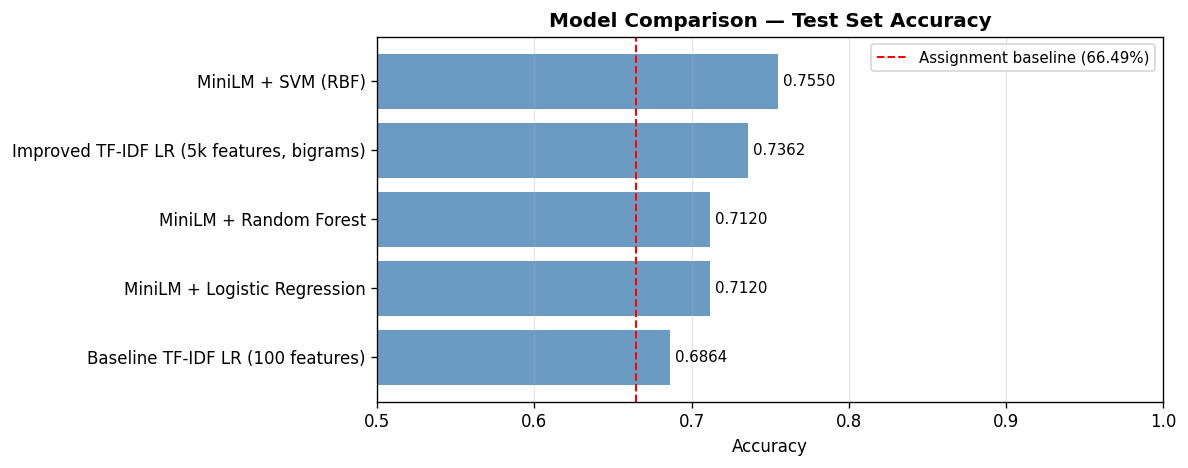


Best model: MiniLM + SVM (RBF) (0.7550)


In [14]:
results = {
    'Baseline TF-IDF LR (100 features)': acc_baseline,
    'Improved TF-IDF LR (5k features, bigrams)': acc_tfidf,
    'MiniLM + Logistic Regression': acc_lr_emb,
    'MiniLM + SVM (RBF)': acc_svm,
    'MiniLM + Random Forest': acc_rf,
}

results_df = pd.Series(results).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(results_df.index, results_df.values, color='steelblue', alpha=0.8)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.axvline(0.6649, color='red', linestyle='--', linewidth=1.2, label='Assignment baseline (66.49%)')
ax.set_xlabel('Accuracy')
ax.set_title('Model Comparison — Test Set Accuracy', fontweight='bold')
ax.set_xlim(0.5, 1.0)
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

best_model_name = results_df.idxmax()
print(f'\nBest model: {best_model_name} ({results_df.max():.4f})')

## 5 — Error Analysis

What is the best model getting wrong? Spot-checking errors often reveals something interesting — are the misclassified headlines genuinely ambiguous, or is there a systematic pattern?

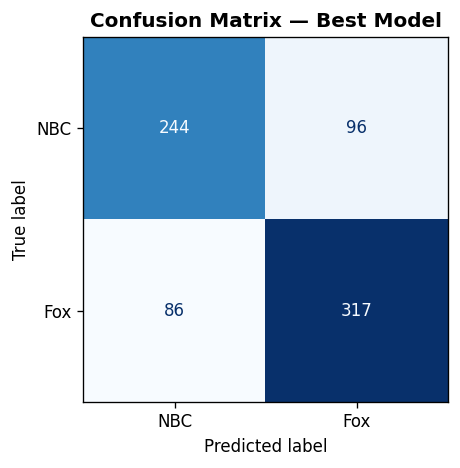

In [17]:
# Use best embedding model for error analysis
# Update y_pred_best to whichever model won above
best_preds = y_pred_svm  # update this if SVM or RF won

test_df = test.copy().reset_index(drop=True)
test_df['predicted'] = best_preds
test_df['correct'] = test_df['predicted'] == test_df['is_fox']

# Confusion matrix
cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NBC', 'Fox'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Best Model', fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Fox headlines misclassified as NBC
fox_as_nbc = test_df[(test_df['is_fox'] == 1) & (test_df['predicted'] == 0)]
print(f'Fox misclassified as NBC: {len(fox_as_nbc)}')
print()
for t in fox_as_nbc['title'].sample(min(8, len(fox_as_nbc)), random_state=42):
    print(' ', t)

Fox misclassified as NBC: 86

  Eddie Van Halen's brother wants AI to complete the band's unreleased music
  Israel targets Hezbollah leader Nasrallah in strike on Beirut headquarters
  Biden admin issues warning to Netanyahu as Israel holds emergency meeting on Gaza aid
  Yazidi woman held hostage for 10 years in Gaza rescued in Israel, US operation
  Israeli ministers frustrated over US, IDF leak on Lebanon operation: Report
  Charlamagne tha God says young Black man predicted Trump's podcast appearance will get him elected
  Israel's ground invasion into Lebanon imminent as cabinet approves next phase of the war
  Israeli military says regular infantry, armored units joining limited ground operation in southern Lebanon


In [19]:
# NBC headlines misclassified as Fox
nbc_as_fox = test_df[(test_df['is_fox'] == 0) & (test_df['predicted'] == 1)]
print(f'NBC misclassified as Fox: {len(nbc_as_fox)}')
print()
for t in nbc_as_fox['title'].sample(min(8, len(nbc_as_fox)), random_state=42):
    print(' ', t)

NBC misclassified as Fox: 96

  S.C. man sentenced to life in prison for murdering Black trans woman after historic verdict
  Poll: Democrats catch up on election enthusiasm, but two key groups lag behind
  In college football showdown, Texas will try beating Georgia at its own game
  Best Rosacea Products for Redness Relief, According to Dermatologists
  Kamala Harris sees path to victory in Pennsylvania running through the suburbs
  A historically Black community grapples with lasting impacts after Baltimore bridge collapse
  The simple reason Kamala Harris is on The Shade Room
  Chuck Todd: Will Biden cost Harris the election?


In [20]:
# Are errors concentrated in certain categories or topics?
if 'category' in test_df.columns:
    error_by_cat = test_df.groupby('category').agg(
        n=('title', 'count'),
        error_rate=('correct', lambda x: 1 - x.mean())
    ).sort_values('error_rate', ascending=False)
    print('Error rate by category (min 5 articles):')
    print(error_by_cat[error_by_cat['n'] >= 5].round(3).to_string())

Error rate by category (min 5 articles):
                 n  error_rate
category                      
nbc-out          6       0.667
us-news         13       0.615
world           58       0.397
politics       231       0.372
other            6       0.333
tech            15       0.267
us              42       0.262
health          13       0.231
travel          14       0.214
sports          49       0.204
asian-america    5       0.200
opinion         10       0.200
lifestyle       12       0.167
select         124       0.073
media           80       0.062
entertainment   23       0.043
science          8       0.000
food-drink      10       0.000
weather          5       0.000
